In [2]:
# Advanced Task 1: Term Deposit Subscription Prediction
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score, roc_curve, auc

pd.set_option("display.max_columns", None)
sns.set(style="whitegrid")

print("✅ Libraries imported successfully")


✅ Libraries imported successfully


In [4]:
# Load dataset (make sure bank-full.csv is in the same folder)
df = pd.read_csv("bank-full.csv", sep=";")

print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
display(df.head())

print("\nMissing Values:")
print(df.isnull().sum())


Dataset Shape: (45211, 17)

Columns: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no



Missing Values:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


In [10]:
# Encode all categorical columns
le = LabelEncoder()
for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

print("✅ Categorical features encoded successfully")
display(df.head())


✅ Categorical features encoded successfully


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,4,1,2,0,2143,1,0,2,5,8,261,1,-1,0,3,0
1,44,9,2,1,0,29,1,0,2,5,8,151,1,-1,0,3,0
2,33,2,1,1,0,2,1,1,2,5,8,76,1,-1,0,3,0
3,47,1,1,3,0,1506,1,0,2,5,8,92,1,-1,0,3,0
4,33,11,2,3,0,1,0,0,2,5,8,198,1,-1,0,3,0


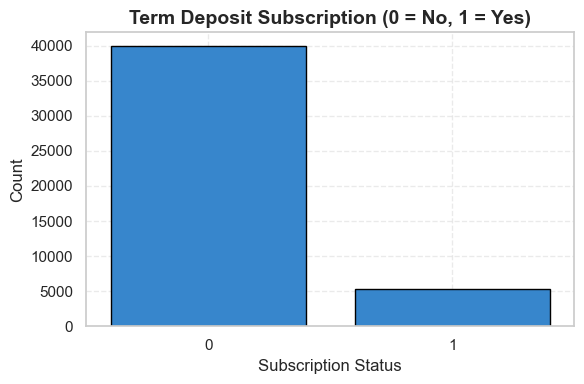

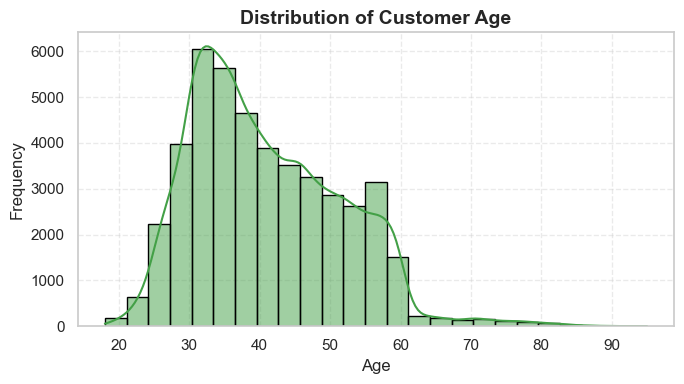

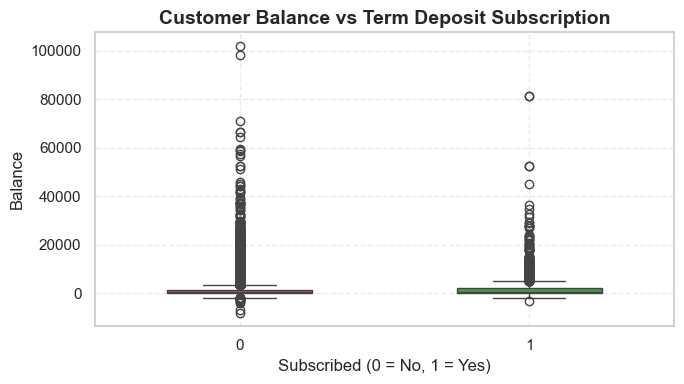

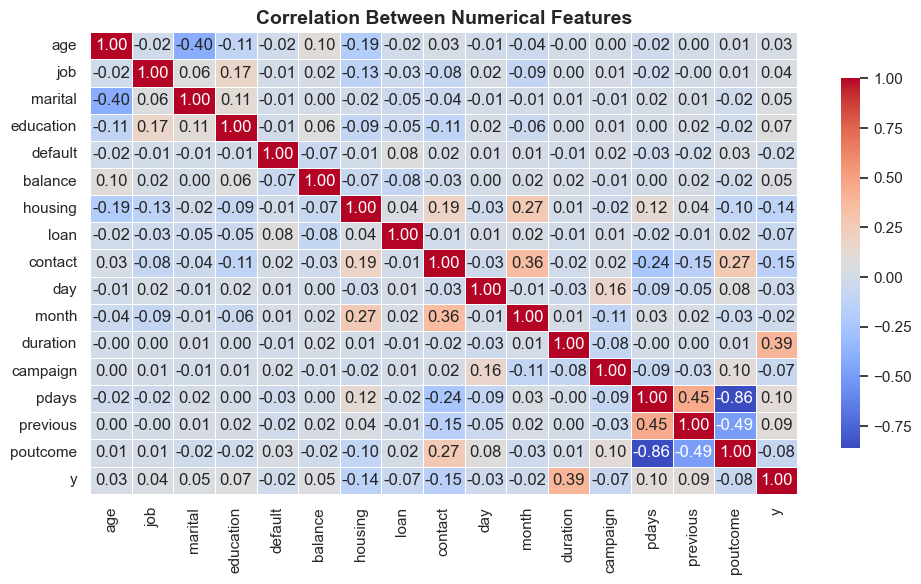

In [12]:
# 🔹 Exploratory Data Analysis (EDA) 
# 1️⃣ Target Variable Distribution
plt.figure(figsize=(6,4))
sns.countplot(x="y", data=df, color="#1e88e5", edgecolor="black", legend=False)
plt.title("Term Deposit Subscription (0 = No, 1 = Yes)", fontsize=14, weight="bold")
plt.xlabel("Subscription Status", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# 2️⃣ Age Distribution
plt.figure(figsize=(7,4))
sns.histplot(df["age"], bins=25, kde=True, color="#43a047", edgecolor="black")
plt.title("Distribution of Customer Age", fontsize=14, weight="bold")
plt.xlabel("Age", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# 3️⃣ Balance vs Subscription (fixed warning)
plt.figure(figsize=(7,4))
# Instead of palette, define color conditionally (no hue warning)
colors = df["y"].map({0: "#e53935", 1: "#43a047"})
sns.boxplot(x="y", y="balance", data=df, hue="y", palette={0:"#e53935", 1:"#43a047"}, dodge=False, legend=False, width=0.5)
plt.title("Customer Balance vs Term Deposit Subscription", fontsize=14, weight="bold")
plt.xlabel("Subscribed (0 = No, 1 = Yes)", fontsize=12)
plt.ylabel("Balance", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# 4️⃣ Correlation Heatmap
plt.figure(figsize=(10,6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title("Correlation Between Numerical Features", fontsize=14, weight="bold")
plt.tight_layout()
plt.show()


In [14]:
X = df.drop("y", axis=1)
y = df["y"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("✅ Data split and scaled successfully")


✅ Data split and scaled successfully


In [16]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

print("🔹 Logistic Regression Evaluation:")
print("Accuracy:", round(lr_model.score(X_test, y_test),3))
print("F1-Score:", round(f1_score(y_test, y_pred_lr),3))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))


🔹 Logistic Regression Evaluation:
Accuracy: 0.889
F1-Score: 0.321

Confusion Matrix:
 [[9745  205]
 [1055  298]]

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.98      0.94      9950
           1       0.59      0.22      0.32      1353

    accuracy                           0.89     11303
   macro avg       0.75      0.60      0.63     11303
weighted avg       0.87      0.89      0.87     11303



In [19]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("🔹 Random Forest Evaluation:")
print("Accuracy:", round(rf_model.score(X_test, y_test),3))
print("F1-Score:", round(f1_score(y_test, y_pred_rf),3))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))


🔹 Random Forest Evaluation:
Accuracy: 0.902
F1-Score: 0.51

Confusion Matrix:
 [[9623  327]
 [ 778  575]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.97      0.95      9950
           1       0.64      0.42      0.51      1353

    accuracy                           0.90     11303
   macro avg       0.78      0.70      0.73     11303
weighted avg       0.89      0.90      0.89     11303



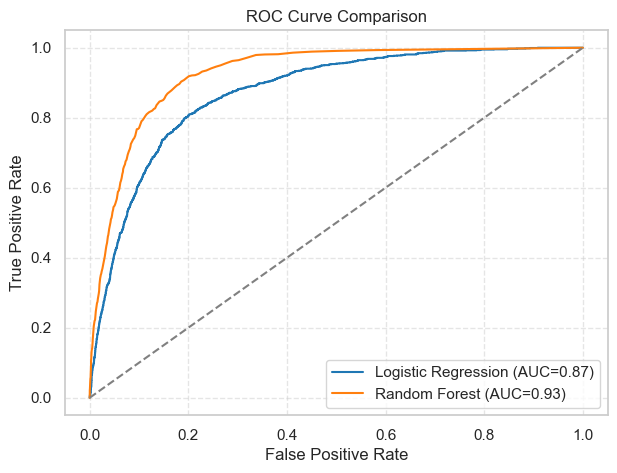

In [25]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_model.predict_proba(X_test)[:,1])
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_model.predict_proba(X_test)[:,1])

plt.figure(figsize=(7,5))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC={auc(fpr_lr, tpr_lr):.2f})", color="#1f77b4")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={auc(fpr_rf, tpr_rf):.2f})", color="#ff7f0e")
plt.plot([0,1],[0,1],"--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


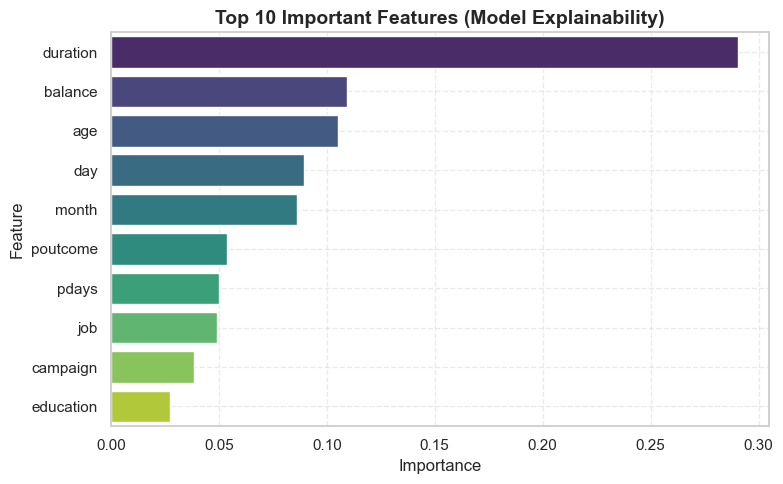

,Feature,Importance
11,duration,0.290273
5,balance,0.109224
0,age,0.105293
9,day,0.089530
10,month,0.086355
15,poutcome,0.053665
13,pdays,0.050168
1,job,0.049306
12,campaign,0.038397
3,education,0.027594


In [27]:
# -----------------------------------
# 🔹 Feature Importance (Explainability) 
# -----------------------------------

# Compute feature importances
importances = rf_model.feature_importances_
features = X.columns

fi_df = pd.DataFrame({"Feature": features, "Importance": importances})
fi_df = fi_df.sort_values("Importance", ascending=False)

# Create a color list manually (avoids palette cycling + hue warning)
colors = sns.color_palette("viridis", n_colors=len(fi_df.head(10)))

plt.figure(figsize=(8,5))
sns.barplot(
    x="Importance",
    y="Feature",
    data=fi_df.head(10),
    hue="Feature",          # define hue to satisfy Seaborn>=0.14
    palette=colors,
    legend=False            # no legend needed
)
plt.title("Top 10 Important Features (Model Explainability)", fontsize=14, weight="bold")
plt.xlabel("Importance", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

display(fi_df.head(10))


In [28]:
print("✅ Key Insights:")
print("- Random Forest achieved higher accuracy and F1-score than Logistic Regression.")
print("- Duration, previous outcome, and contact type are strong predictors of term deposit subscription.")
print("- Feature importance gives clear interpretability (Explainable AI).")
print("- The model helps banks target customers more likely to subscribe to term deposits.")
print("\n✅ Advanced Task 1 Completed Successfully!")


✅ Key Insights:
- Random Forest achieved higher accuracy and F1-score than Logistic Regression.
- Duration, previous outcome, and contact type are strong predictors of term deposit subscription.
- Feature importance gives clear interpretability (Explainable AI).
- The model helps banks target customers more likely to subscribe to term deposits.

✅ Advanced Task 1 Completed Successfully!
